### 1. Import Library

In [1]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_excel("../Data/Dataset_Lengkap Baru fix.xlsx")

print("Jumlah Data :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

df.head()

Jumlah Data : 3000
Jumlah Kolom : 3


,title,abstract,label
0,Authorship Attribution of Short Historical Ara...,Authorship Attribution (AA) is a task that aim...,computer science
1,Critical Barriers in Software Outsourcing Vend...,Globalization and technological advancement ha...,computer science
2,Adopting Intelligent Modelling to Trace Fault ...,Aiming at building new global optical network ...,computer science
3,SCUTMA: Selecting Components for Unit Testing ...,Context The source code of a mobile applicatio...,computer science
4,Using Expert Evaluation to Assess the Implemen...,It has been argued that the use of persuasive ...,computer science


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     3000 non-null   object
 1   abstract  3000 non-null   object
 2   label     3000 non-null   object
dtypes: object(3)
memory usage: 70.4+ KB


### 2. Prepocessing Data

In [6]:
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    'Kolom': missing_values.index,
    'Jumlah Missing Value': missing_values.values
})

missing_df

,Kolom,Jumlah Missing Value
0,title,0
1,abstract,0
2,label,0


In [7]:
duplicate_data = df.duplicated().sum()

print("Jumlah Data Duplikat :", duplicate_data)

Jumlah Data Duplikat : 0


In [8]:
df['text'] = df['title'].fillna('') + ' ' + df['abstract'].fillna('')

df[['title', 'abstract', 'text']].head()

,title,abstract,text
0,Authorship Attribution of Short Historical Ara...,Authorship Attribution (AA) is a task that aim...,Authorship Attribution of Short Historical Ara...
1,Critical Barriers in Software Outsourcing Vend...,Globalization and technological advancement ha...,Critical Barriers in Software Outsourcing Vend...
2,Adopting Intelligent Modelling to Trace Fault ...,Aiming at building new global optical network ...,Adopting Intelligent Modelling to Trace Fault ...
3,SCUTMA: Selecting Components for Unit Testing ...,Context The source code of a mobile applicatio...,SCUTMA: Selecting Components for Unit Testing ...
4,Using Expert Evaluation to Assess the Implemen...,It has been argued that the use of persuasive ...,Using Expert Evaluation to Assess the Implemen...


### Preprocessing - Cleaning

In [9]:
import re # menghapus semua karakter selain huruf dan spasi

# simpan teks sebelum cleaning
df['cleaning_before'] = df['text']

# cleaning
df['cleaning_after'] = df['cleaning_before'].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', str(x))
)

df[['cleaning_before', 'cleaning_after']].head()

,cleaning_before,cleaning_after
0,Authorship Attribution of Short Historical Ara...,Authorship Attribution of Short Historical Ara...
1,Critical Barriers in Software Outsourcing Vend...,Critical Barriers in Software Outsourcing Vend...
2,Adopting Intelligent Modelling to Trace Fault ...,Adopting Intelligent Modelling to Trace Fault ...
3,SCUTMA: Selecting Components for Unit Testing ...,SCUTMA Selecting Components for Unit Testing i...
4,Using Expert Evaluation to Assess the Implemen...,Using Expert Evaluation to Assess the Implemen...


### Preprocessing - Case folding

In [10]:
# mengubah semua teks menjadi huruf kecil
df['casefold_before'] = df['cleaning_after']

df['casefold_after'] = df['casefold_before'].str.lower()

df[['casefold_before', 'casefold_after']].head()

,casefold_before,casefold_after
0,Authorship Attribution of Short Historical Ara...,authorship attribution of short historical ara...
1,Critical Barriers in Software Outsourcing Vend...,critical barriers in software outsourcing vend...
2,Adopting Intelligent Modelling to Trace Fault ...,adopting intelligent modelling to trace fault ...
3,SCUTMA Selecting Components for Unit Testing i...,scutma selecting components for unit testing i...
4,Using Expert Evaluation to Assess the Implemen...,using expert evaluation to assess the implemen...


### Preprocessing - Tokenizing

In [11]:
# memecah teks menjadi kata-kata (token)
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')

# menyimpan hasil sebelum tokenizing
df['tokenizing_before'] = df['casefold_after']

# tokenizing
df['tokenizing_after'] = df['tokenizing_before'].apply(word_tokenize)

df[['tokenizing_before', 'tokenizing_after']].head()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenov\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,tokenizing_before,tokenizing_after
0,authorship attribution of short historical ara...,"[authorship, attribution, of, short, historica..."
1,critical barriers in software outsourcing vend...,"[critical, barriers, in, software, outsourcing..."
2,adopting intelligent modelling to trace fault ...,"[adopting, intelligent, modelling, to, trace, ..."
3,scutma selecting components for unit testing i...,"[scutma, selecting, components, for, unit, tes..."
4,using expert evaluation to assess the implemen...,"[using, expert, evaluation, to, assess, the, i..."


### Preprocessing - Stopword Removal

In [12]:
# menghapus kata-kata yang termasuk stopword
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# menyimpan hasil sebelum stopword removal
df['stopword_before'] = df['tokenizing_after']

# menghapus stopword
df['stopword_after'] = df['stopword_before'].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

df[['stopword_before', 'stopword_after']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenov\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,stopword_before,stopword_after
0,"[authorship, attribution, of, short, historica...","[authorship, attribution, short, historical, a..."
1,"[critical, barriers, in, software, outsourcing...","[critical, barriers, software, outsourcing, ve..."
2,"[adopting, intelligent, modelling, to, trace, ...","[adopting, intelligent, modelling, trace, faul..."
3,"[scutma, selecting, components, for, unit, tes...","[scutma, selecting, components, unit, testing,..."
4,"[using, expert, evaluation, to, assess, the, i...","[using, expert, evaluation, assess, implementa..."


### Preprocessing - Stemming

In [13]:
# mengubah kata menjadi bentuk dasar
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

# simpan sebelum stemming
df['stemming_before'] = df['stopword_after']

# fungsi stemming
def stem_text(tokens):
    return [stemmer.stem(word) for word in tokens]

# apply stemming
df['stemming_after'] = df['stemming_before'].apply(stem_text)

df[['stemming_before', 'stemming_after']].head()

,stemming_before,stemming_after
0,"[authorship, attribution, short, historical, a...","[authorship, attribut, short, histor, arab, te..."
1,"[critical, barriers, software, outsourcing, ve...","[critic, barrier, softwar, outsourc, vendor, o..."
2,"[adopting, intelligent, modelling, trace, faul...","[adopt, intellig, model, trace, fault, undergr..."
3,"[scutma, selecting, components, unit, testing,...","[scutma, select, compon, unit, test, mobil, ap..."
4,"[using, expert, evaluation, assess, implementa...","[use, expert, evalu, assess, implement, persua..."


### Hasil Preprocessing final

In [14]:
# menggabungkan kembali token hasil stemming menjadi kalimat

df['final_text'] = df['stemming_after'].apply(
    lambda tokens: ' '.join(tokens)
)

df[['text', 'final_text']].head()

,text,final_text
0,Authorship Attribution of Short Historical Ara...,authorship attribut short histor arab text use...
1,Critical Barriers in Software Outsourcing Vend...,critic barrier softwar outsourc vendor organ i...
2,Adopting Intelligent Modelling to Trace Fault ...,adopt intellig model trace fault underground o...
3,SCUTMA: Selecting Components for Unit Testing ...,scutma select compon unit test mobil applic co...
4,Using Expert Evaluation to Assess the Implemen...,use expert evalu assess implement persuas desi...


### 3. TF-IDF

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['final_text'])

y = df['label']

print("Shape TF-IDF :", X.shape)
print("Jumlah Fitur :", len(tfidf.get_feature_names_out()))

Shape TF-IDF : (3000, 18709)
Jumlah Fitur : 18709


In [16]:
feature_names = tfidf.get_feature_names_out()

tfidf_example = pd.DataFrame(
    X[0].T.toarray(),
    index=feature_names,
    columns=['TF-IDF']
)

tfidf_example = tfidf_example[tfidf_example['TF-IDF'] > 0]

tfidf_example.sort_values(
    by='TF-IDF',
    ascending=False
).head(10)

,TF-IDF
knn,0.390480
aa,0.362277
stylometri,0.353837
text,0.319171
authorship,0.236129
featur,0.187151
charact,0.182297
histor,0.180016
short,0.177838
arab,0.168193


### 4. Pemodelan dan Klasifikasi Menggunakan SVM

### 4.1 Pembagian Data Training dan Testing

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data Training :", X_train.shape)
print("Data Testing :", X_test.shape)

Data Training : (2400, 18709)
Data Testing : (600, 18709)


### 4.2. Training Model SVM

In [28]:
from sklearn.svm import SVC

# membuat model SVM Linear
model = SVC(kernel='linear')

# training model
model.fit(X_train, y_train)

print(model)

SVC(kernel='linear')


### 5. Evaluasi Model

### 5.1 Accuracy, Precision, Recall, F1-Score

In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# prediksi data testing
y_pred = model.predict(X_test)

# accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Model SVM :", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy Model SVM : 0.9716666666666667

Classification Report:

                  precision    recall  f1-score   support

computer science       0.96      0.96      0.96       217
         economy       0.97      0.98      0.98       186
         medical       0.98      0.97      0.98       197

        accuracy                           0.97       600
       macro avg       0.97      0.97      0.97       600
    weighted avg       0.97      0.97      0.97       600



### 5.2 Confusion Matrix

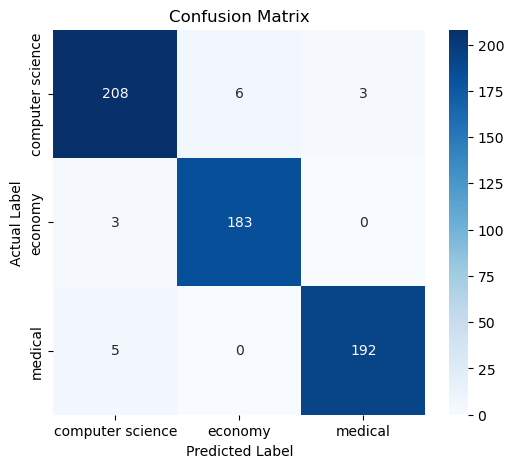

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')

plt.show()

### 7. WordCloud

In [34]:
!pip install wordcloud

  Obtaining dependency information for wordcloud from https://files.pythonhosted.org/packages/45/70/0041966d469dec79036ad3962b83b007004b842531ee7c41bdba61310eb6/wordcloud-1.9.6-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   -------- ------------------------------- 61.4/306.1 kB 1.6 MB/s eta 0:00:01
   -------- ------------------------------- 61.4/306.1 kB 1.6 MB/s eta 0:00:01
   ---------------------- ----------------- 174.1/306.1 kB 1.3 MB/s eta 0:00:01
   ------------------------- -------------- 194.6/306.1 kB 1.2 MB/s eta 0:00:01
   -------------------------------- ------- 245.8/306.1 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 306.1/306.1 kB 1.1 MB/s eta 0:00:00


In [35]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

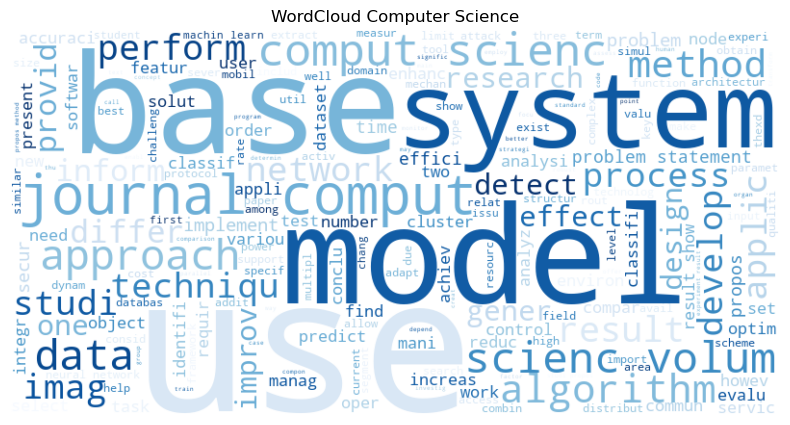

In [39]:
text_cs = ' '.join(df[df['label'] == 'computer science']['final_text'])

wordcloud_cs = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Blues'
).generate(text_cs)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_cs, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Computer Science')
plt.show()

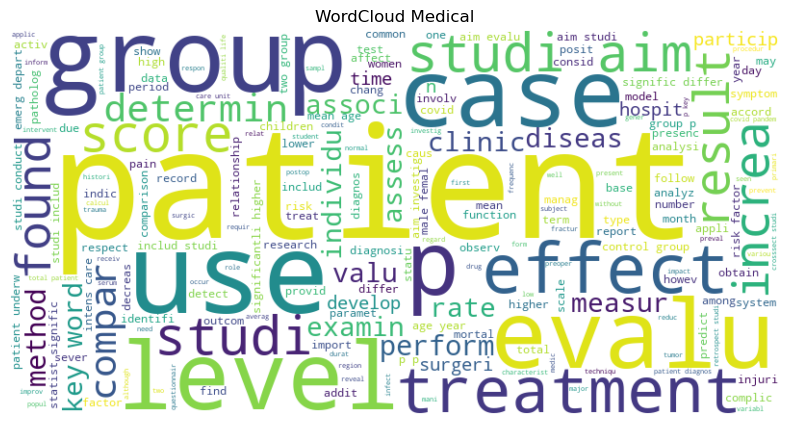

In [41]:
text_med = ' '.join(
    df[df['label'] == 'medical']['final_text']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text_med)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Medical')
plt.show()

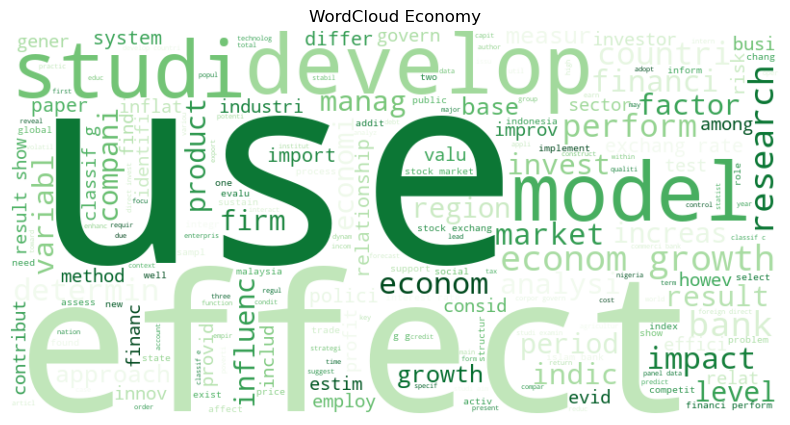

In [42]:
text_eco = ' '.join(df[df['label'] == 'economy']['final_text'])

wordcloud_eco = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens'
).generate(text_eco)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_eco, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Economy')
plt.show()

### 8. Simpan Model

In [43]:
import pickle

pickle.dump(model, open('svm_model.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb'))

print("Model dan TF-IDF berhasil disimpan!")

Model dan TF-IDF berhasil disimpan!
